# 01 · Data preprocessing

**Canadian Survey on Business Conditions** : four quarterly extracts, Q3 2023 to Q2 2024.

Every survey wave asks business owners whether they expect **Employment, Sales, Profitability** and
**Investment** to *increase*, *stay about the same*, or *decrease* over the next three months,
broken down by geography and by industry.

This notebook turns four raw files into one analysis-ready dataset, and documents every judgement
made along the way: what was renamed, what was missing, what looked abnormal, and what was
deliberately left alone.

**Run order:** `01` → `02` → `03` → `04` → `05` → `06` → `07`.

## Setup

All shared logic lives in `src/csbc.py`. Paths are anchored to that file's location, so the project
runs from any device using the zip file.

In [ ]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


## Step 1 : What arrived

Six columns per file. `VALUE` is the percentage of business owners in that group giving that answer.

In [ ]:
raw_paths = sorted(csbc.RAW_DIR.glob("*.csv"))
first = csbc.read_csv(raw_paths[0])

print(f"{raw_paths[0].name}: {len(first):,} rows x {first.shape[1]} columns\n")
first.head(4)

Data CSBC-Q1 2024.csv: 2,352 rows x 6 columns



,GEO,Business_characteristics,Business_information,Expected_change,VALUE,Quarter
0,Canada,North American Industry Classification Syste...,Employment,increase,11.1,Q1 2024
1,Canada,North American Industry Classification Syste...,Employment,stay about the same,82.9,Q1 2024
2,Canada,North American Industry Classification Syste...,Employment,decrease,6.0,Q1 2024
3,Canada,North American Industry Classification Syste...,Sales,increase,17.8,Q1 2024


In [ ]:
# The four dimensions, and how they multiply out to the row count. If this identity ever
# breaks, the file is not the shape the analysis assumes.
for column in ["GEO", "Business_characteristics", "Business_information", "Expected_change"]:
    print(f"{column:26s} {first[column].nunique():3d} distinct")

expected = (first["GEO"].nunique() * first["Business_characteristics"].nunique()
            * first["Business_information"].nunique() * first["Expected_change"].nunique())
print(f"\n14 geographies x 14 characteristics x 4 metrics x 3 directions = {expected:,}")
print(f"actual rows = {len(first):,}  ->  a complete grid, no gaps in coverage")

GEO                         14 distinct
Business_characteristics    14 distinct
Business_information         4 distinct
Expected_change              3 distinct

14 geographies x 14 characteristics x 4 metrics x 3 directions = 2,352
actual rows = 2,352  ->  a complete grid, no gaps in coverage


The grid is complete: **14 geographies** (Canada plus 13 provinces and territories) × **14 business
characteristics** (all-industries plus 13 industries) × 4 metrics × 3 directions = 2,352 rows.

Worth noting early: only **1 of the 14 geographies is Canada**, so a Canada-only analysis would
leave roughly 93% of the rows unused. Notebook `05` uses them.

## Step 2: Label drift

Q2 2024 renames two labels. The mappings are **explicit in code, never fuzzy-matched**, so a label
nobody has mapped yet fails validation instead of quietly starting a second, parallel series.

| Raw Q2 2024 label | Canonical label |
|---|---|
| `Capital Investment` | `Investment` |
| `stay the same` | `stay about the same` |

In [4]:
# Counted before normalisation: applying the fix first would erase the evidence of drift.
for path in raw_paths:
    frame = csbc.read_csv(path)
    hits = {
        "Capital Investment": int((frame["Business_information"] == "Capital Investment").sum()),
        "stay the same": int((frame["Expected_change"] == "stay the same").sum()),
    }
    flag = "  <-- drift" if any(hits.values()) else ""
    print(f"{path.name:28s} {hits}{flag}")

Data CSBC-Q1 2024.csv        {'Capital Investment': 0, 'stay the same': 0}
Data CSBC-Q2 2024.csv        {'Capital Investment': 588, 'stay the same': 784}  <-- drift
Data CSBC-Q3 2023.csv        {'Capital Investment': 0, 'stay the same': 0}
Data CSBC-Q4 2023.csv        {'Capital Investment': 0, 'stay the same': 0}


## Step 3: Load, normalise, validate

Seven checks run on every file. Five **raise** (a structural problem must stop the load); two
**warn** and record a metric (a characteristic of the data should be surfaced, not hidden).

| # | Check | On failure |
|---|---|---|
| 1 | All six required columns present | raise |
| 2 | Exactly one valid `Q# YYYY` per incoming file | raise |
| 3 | `VALUE` numeric and within 0–100 | raise |
| 4 | No duplicate `GEO × characteristic × metric × direction × quarter` | raise |
| 5 | Only known category labels after aliasing | raise |
| 6 | Each group has all three direction rows | warn |
| 7 | Missing percentages | warn + retain |

In [ ]:
combined, per_file, combined_result = csbc.combine_quarters(raw_paths)

pd.DataFrame([
    {
        "file": r.source,
        "rows": r.metrics["rows"],
        "quarter": ", ".join(r.metrics["quarters"]),
        "missing VALUE": r.metrics["missing_values"],
        "duplicate keys": r.metrics["duplicate_keys"],
        "labels rewritten": sum(r.metrics["aliases_normalized"].values()),
    }
    for r in per_file
])

,file,rows,quarter,missing VALUE,duplicate keys,labels rewritten
0,Data CSBC-Q1 2024.csv,2352,Q1 2024,0,0,0
1,Data CSBC-Q2 2024.csv,2352,Q2 2024,7,0,1372
2,Data CSBC-Q3 2023.csv,2352,Q3 2023,0,0,0
3,Data CSBC-Q4 2023.csv,2352,Q4 2023,0,0,0


In [ ]:
for result in [*per_file, combined_result]:
    if result.warnings:
        print(result.source)
        for warning in result.warnings:
            print(f"   ! {warning}")

Data CSBC-Q1 2024.csv
   ! 345 complete triplet(s) sum materially below 100; no renormalisation applied.
   ! 33 group(s) are empty (all three shares zero).
Data CSBC-Q2 2024.csv
   ! 7 VALUE cell(s) missing; retained as missing.
   ! 338 complete triplet(s) sum materially below 100; no renormalisation applied.
   ! 38 group(s) are empty (all three shares zero).
Data CSBC-Q3 2023.csv
   ! 371 complete triplet(s) sum materially below 100; no renormalisation applied.
   ! 27 group(s) are empty (all three shares zero).
Data CSBC-Q4 2023.csv
   ! 369 complete triplet(s) sum materially below 100; no renormalisation applied.
   ! 24 group(s) are empty (all three shares zero).
combined
   ! 7 VALUE cell(s) missing; retained as missing.
   ! 1423 complete triplet(s) sum materially below 100; no renormalisation applied.
   ! 122 group(s) are empty (all three shares zero).


## Step 4: Missing data

Seven `VALUE` cells are missing, all in Q2 2024. Rather than just counting them, it is worth asking
**where** they sit; the pattern tells you what kind of problem this is.

In [ ]:
q2 = csbc.read_csv(csbc.RAW_DIR / "Data CSBC-Q2 2024.csv")
gaps = q2[q2["VALUE"].isna()]

print(f"{len(gaps)} missing cells, at file row positions: {gaps.index.tolist()}")
print(f"the file has {len(q2):,} rows, so every gap is in the first {gaps.index.max() + 1}\n")
print("by response direction:")
print(gaps["Expected_change"].value_counts().to_string())

7 missing cells, at file row positions: [2, 5, 8, 11, 13, 14, 17]
the file has 2,352 rows, so every gap is in the first 18

by response direction:
Expected_change
decrease         6
stay the same    1


In [ ]:
gaps[["Business_characteristics", "Business_information", "Expected_change"]]

,Business_characteristics,Business_information,Expected_change
2,North American Industry Classification Syste...,Employment,decrease
5,North American Industry Classification Syste...,Sales,decrease
8,North American Industry Classification Syste...,Profitability,decrease
11,North American Industry Classification Syste...,Capital Investment,decrease
13,"Agriculture, forestry, fishing and hunting",Employment,stay the same
14,"Agriculture, forestry, fishing and hunting",Employment,decrease
17,"Agriculture, forestry, fishing and hunting",Sales,decrease


**Diagnosis.** All seven gaps sit in the **first 18 rows of one file**, and **six of the seven are
the `decrease` response**. Survey suppression would scatter across small cells throughout the file;
this is clustered at the top of the file and concentrated in one column. It reads as an
**export or copy artifact**, not a survey-level suppression rule.

**Decision: flag and retain, never impute.** In particular the tempting fill:
`decrease = 100 − increase − stay about the same` —> is *wrong here*, and Step 5 shows why.

The analyses are then designed so their published numbers depend only on observed values:
notebook `03` uses observed `increase` shares; notebook `04` asserts that `increase` and `decrease`
are both present before computing anything.

## Step 5: Abnormalities

Two things in this data look wrong at first glance and need separating, because they call for
different handling.

In [ ]:
triplets = csbc.triplet_sums(combined)
triplets["residual"] = 100 - triplets["sum"]

# "Empty" means literally all three shares zero - no tolerance to justify.
empty = triplets[triplets["sum"] == 0]
short = triplets[(triplets["sum"] > 0) & ~triplets["sum"].between(99.8, 100.2)]
exact = triplets[triplets["sum"].between(99.8, 100.2)]

print(f"complete groups (all three directions present): {len(triplets):,}")
print(f"  sum to ~100                                 : {len(exact):,}")
print(f"  sum materially below 100                    : {len(short):,}")
print(f"  entirely empty (all three shares zero)      : {len(empty):,}")

complete groups (all three directions present): 3,130
  sum to ~100                                 : 1,585
  sum materially below 100                    : 1,423
  entirely empty (all three shares zero)      : 122


### Abnormality A: empty cells

**122 groups have all three shares at zero.** These are *absent* cells, not partial answers: a
group too small to report anything. They are counted separately rather than lumped in with
"incomplete", because averaging them in would drag every residual statistic toward zero and hide
the real pattern.

### Abnormality B: the three shares do not sum to 100

This is the important one, and it is **not random noise**. The shortfall is overwhelmingly
concentrated in a single metric.

In [ ]:
csbc.residual_by_metric(combined)

,groups,mean_residual,median_residual,max_residual
Business_information,,,,
Sales,752,6.4,0.2,99.2
Employment,749,2.2,0.0,97.9
Profitability,751,6.5,0.1,98.5
Investment,756,18.5,14.1,98.7


In [ ]:
# The same picture at the headline level a stakeholder would actually read.
national = triplets[(triplets["GEO"] == "Canada")
                    & (triplets["Business_characteristics"] == csbc.ALL_INDUSTRIES)]

# Chronological, not alphabetical: 'Q1 2024' sorts before 'Q3 2023' as a string.
(national.pivot(index="Business_information", columns="Quarter", values="residual")
         .reindex(index=csbc.METRIC_ORDER, columns=csbc.sort_quarters(national["Quarter"]))
         .round(1))

Quarter,Q3 2023,Q4 2023,Q1 2024
Business_information,,,
Sales,3.4,3.4,3.8
Employment,0.0,0.0,0.0
Profitability,2.9,2.7,2.6
Investment,15.3,14.9,16.1


**Q2 2024 is absent from that table by design** : it is the quarter whose `decrease` cells are
missing, so those groups never had all three rows to sum. The two abnormalities are connected: the
missing cells sit in exactly the rows this diagnostic needs.

**Employment's three shares sum to exactly 100. Investment's sum to about 84.**

So roughly **one business in six gives no directional answer on Investment**, against essentially
none on Employment. That is a property of the *question*, not a data error; and it becomes the
central finding of this analysis. Notebook `02` confirms it from a second, independent angle.

**Decision: do not renormalise, and do not infer the missing `decrease` values.** There is no
single residual to redistribute; its size depends on which metric you are looking at. Rescaling
would invent responses the survey never recorded, and would do so unevenly across metrics.

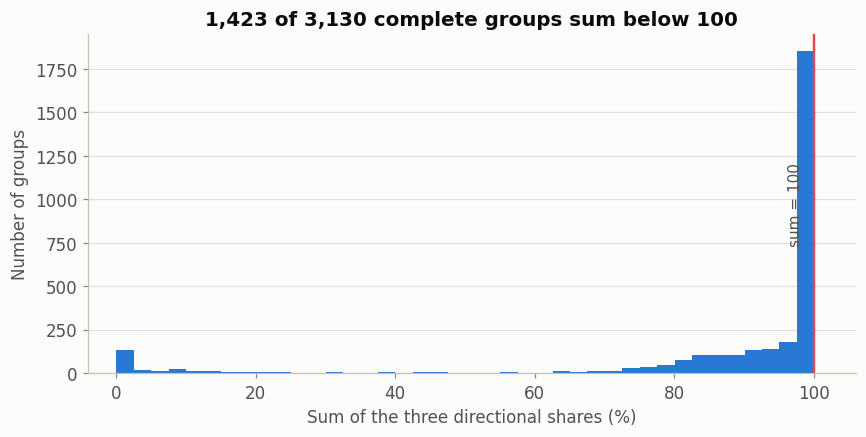

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(triplets["sum"], bins=40, color=csbc.SERIES_COLOR["Sales"], zorder=2)
ax.axvline(100, color=csbc.NEGATIVE, linewidth=1.6, zorder=3)
ax.text(98.4, ax.get_ylim()[1] * 0.5, "sum = 100", rotation=90, ha="right", va="center",
        fontsize=10, color=csbc.INK_SOFT)
ax.set_title(f"{len(short):,} of {len(triplets):,} complete groups sum below 100")
ax.set_xlabel("Sum of the three directional shares (%)")
ax.set_ylabel("Number of groups")
ax.set_xlim(-4, 106)
ax.grid(axis="y")
ax.set_axisbelow(True)
fig.savefig(csbc.OUTPUT_DIR / "preprocessing_triplet_sums.png")
plt.show()

The spike at 100 is Employment and most of Profitability and Sales; the long left tail is
Investment. The small cluster at zero is the 122 empty cells.

## Step 6: Write the clean dataset

One file for every downstream notebook, plus a machine-generated audit trail.

In [ ]:
combined.to_csv(csbc.PROCESSED_FILE, index=False)
report = csbc.quality_report(per_file, combined_result,
                             csbc.OUTPUT_DIR / "data_quality_report.txt")

print(f"wrote data/processed/{csbc.PROCESSED_FILE.name}  ({len(combined):,} rows)")
print(f"wrote outputs/data_quality_report.txt\n")
print(report[-780:])

wrote data/processed/combined_csbc.csv  (9,408 rows)
wrote outputs/data_quality_report.txt

rters: Q3 2023, Q4 2023, Q1 2024, Q2 2024
  Missing VALUE cells: 7
  Duplicate natural keys: 0
  Empty groups (all three shares zero): 122
  Triplets short of 100: 1423 of 3130

Decisions:
  Missing percentages are retained as missing, never back-calculated.
  Directional shares are not renormalized to 100: the residual is real and
  strongly metric-specific (largest for Investment), so redistributing it
  would invent responses the survey did not record.
  Empty groups are reported separately from partial ones - they are absent
  cells rather than incomplete answers.


## Summary of preprocessing decisions

| Issue found | Decision | Why |
|---|---|---|
| Two renamed labels in Q2 2024 | Map explicitly | An unknown label should fail loudly, not split a series silently |
| 7 missing `VALUE` cells | Flag, retain, never impute | Clustered in one file's first rows and in one response — an export artifact, and no safe residual exists |
| 122 all-zero groups | Count separately from partial ones | Absent cells, not incomplete answers |
| Shares summing below 100 | Report, never rescale | The residual is real and metric-specific (Investment ~15 pp, Employment ~0 pp) |
| Duplicate natural keys | None found; would raise | Appending duplicates would double-count groups |

---

**Next:** `02_understanding_data.ipynb` what the data looks like before any analysis, including
whether these four metrics move together.

